<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QEF007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# QFT007: Mass Basin Mapping
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000
timesteps = 300
lambda_val = 1.0
mass_values = [0.1, 0.5, 1.0, 2.0, 5.0]
seed = 42
np.random.seed(seed)

def init_packet(N, mass):
    packet = np.zeros(N)
    packet[N//2 - 10:N//2 + 10] = mass * 2.0
    return packet


In [2]:
def evolve(state, timesteps, lambda_val, mass):
    history = []
    s = state.copy()
    for t in range(timesteps):
        drift = np.roll(s, -1) - np.roll(s, 1)
        s = s + lambda_val * np.sin(s) + (0.05 / mass) * drift
        history.append(s.copy())
    return np.array(history)


In [3]:
basins = {}

for m in mass_values:
    state = init_packet(N, m)
    hist = evolve(state, timesteps, lambda_val, m)
    final = hist[-1]
    basin_center = np.argmax(np.abs(final))
    basins[m] = basin_center


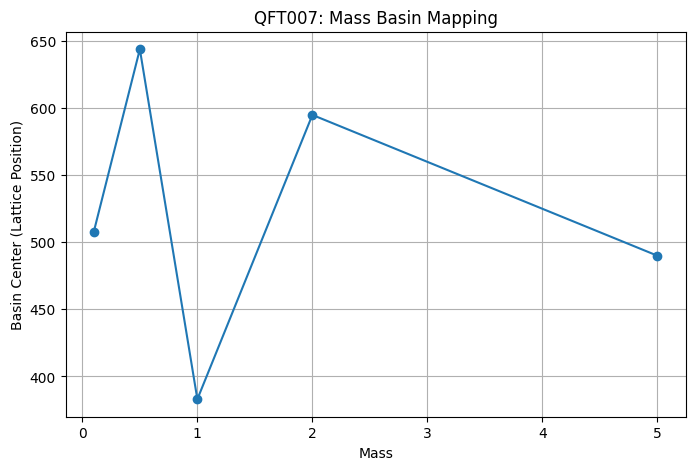

In [4]:
plt.figure(figsize=(8,5))
plt.plot(mass_values, [basins[m] for m in mass_values], marker='o')
plt.xlabel("Mass")
plt.ylabel("Basin Center (Lattice Position)")
plt.title("QFT007: Mass Basin Mapping")
plt.grid(True)
plt.show()
